In [22]:
# ==============================
# 一、电价预测主框架
# ==============================

# --- 1. 数据读取与特征工程 ---
# （1）读取原始数据（发电量、负荷、气象、电价）
# （2）时间对齐、缺失值处理
# （3）特征构造：滞后项、移动平均、气象滞后特征、日内小时变量
# （4）划分训练集与测试集（TimeSeriesSplit）

# --- 2. 相关性分析与特征筛选 ---
# （1）计算特征与目标电价的皮尔逊/斯皮尔曼相关系数
# （2）剔除共线性强的特征（如 VIF > 10）
# （3）绘制热力图、保存相关性矩阵
# （4）可选择用模型（如 Lasso）自动选特征

# --- 3. 电价预测模型训练与验证 ---
# （1）模型选择：线性模型 / 树模型 / LSTM / XGBoost
# （2）TimeSeriesSplit 交叉验证
# （3）模型评估指标：MAE、RMSE、R²
# （4）保存模型与预测结果（逐小时拼接）

# ==============================
# 二、预测输出与可视化
# ==============================

# （1）绘制预测 vs 实际电价曲线（每日/整月）
# （2）导出预测结果到 Excel
# （3）按小时统计预测误差


# 1.数据读取及特征工程

In [3]:
# 数据读取代码
import pandas as pd
from datetime import datetime

# 读取气象数据
df_weather = pd.read_excel("D:\\工作\\特变电工\\13项目\\电价预测\\数据源\\open-meteo-40.11N113.32E1049m.xlsx",skiprows=12, header=0)
df_weather=df_weather.drop(df_weather.columns[[5,6]],axis=1)
# 处理时间列
df_weather['datetime'] = pd.to_datetime(df_weather['time'])
# 定义地区location_id 对应的权重
weights = {
    0: 0.1,
    1: 0.1,
    2: 0.1,
    3: 0.1,
    4: 0.1,
    5: 0.1,
    6: 0.1,
    7: 0.1,
    8: 0.1,
    9: 0.1
}
df_weather['权重']=df_weather["location_id"].map(weights)
df_weather["加权温度数据(°C)"] = df_weather["temperature_2m (°C)"] * df_weather['权重']
df_weather["加权100米风速数据（m/s）"] = df_weather["wind_speed_100m (m/s)"] * df_weather['权重']
df_weather["加权辐照度（W/m²）"] = df_weather["shortwave_radiation (W/m²)"] * df_weather['权重']

df_weather_groupedbyDate=df_weather.groupby('datetime')[["加权温度数据(°C)","加权100米风速数据（m/s）","加权辐照度（W/m²）"]].sum()
# df_weather_groupedbyDate = df_weather_groupedbyDate[df_weather_groupedbyDate.index >= '2022-01-01']
# df_weather_groupedbyDate

In [4]:
# 将1小时分辨率气象数据转换为15min
df_weather_groupedbyDate_resampled=df_weather_groupedbyDate.resample('15T').mean().interpolate(method='linear')  # 将数据重采样到15分钟,线性插值填补缺失值 
df_weather_groupedbyDate_resampled

,加权温度数据(°C),加权100米风速数据（m/s）,加权辐照度（W/m²）
datetime,,,
2021-01-01 00:00:00,-10.850,4.49200,0.0
2021-01-01 00:15:00,-10.825,4.46525,0.0
2021-01-01 00:30:00,-10.800,4.43850,0.0
2021-01-01 00:45:00,-10.775,4.41175,0.0
2021-01-01 01:00:00,-10.750,4.38500,0.0
...,...,...,...
2024-12-31 22:00:00,-2.870,2.27800,0.0
2024-12-31 22:15:00,-3.030,2.21325,0.0
2024-12-31 22:30:00,-3.190,2.14850,0.0


In [5]:
# 读取供需数据
df_DS = pd.read_excel("D:\\工作\\特变电工\\13项目\\电价预测\\数据源\\公有数据-供需数据-日前（2022-01-01至2024-12-31）.xlsx", header=0)

In [6]:
# 读取电价数据
df_Price = pd.read_excel("D:\\工作\\特变电工\\13项目\\电价预测\\数据源\\公有数据-出清量价（2022-01-01至2024-12-31）.xlsx",header=0)

In [7]:
df_DS
# 将 '日期' 和 '时间' 列合并为 datetime 并设为索引
df_DS['时间'] = df_DS['时间'].replace('24:00', '00:00')
df_DS['datetime'] = pd.to_datetime(df_DS['日期'] + ' ' + df_DS['时间'])
df_DS = df_DS.set_index('datetime')

# 删除原 '日期' 和 '时间' 列（可选）
df_DS = df_DS.drop(columns=['日期', '时间'])
# df_DS

In [8]:
# df_Price
# 将 '日期' 和 '时间' 列合并为 datetime 并设为索引
df_Price['时间'] = df_Price['时间'].replace('24:00', '00:00')
df_Price['datetime'] = pd.to_datetime(df_Price['日期'] + ' ' + df_Price['时间'])
df_Price = df_Price.set_index('datetime')

# 删除原 '日期' 和 '时间' 列（可选）
df_Price = df_Price.drop(columns=['日期', '时间'])
# df_Price

In [9]:
# 截取共同时间段
start_time = max(df_weather_groupedbyDate.index.min(), df_DS.index.min(), df_Price.index.min())
end_time = min(df_weather_groupedbyDate.index.max(), df_DS.index.max(), df_Price.index.max())

df_weather_groupedbyDate_resampled = df_weather_groupedbyDate_resampled.loc[start_time:end_time]
df_DS = df_DS.loc[start_time:end_time]
df_Price = df_Price.loc[start_time:end_time]
df_Price

,统一出清价格-日前\n（元/MWh）,统一出清价格-实时\n（元/MWh）,现货出清电量-日前\n（MWh）,现货出清电量-实时\n（MWh）
datetime,,,,
2022-01-01 00:00:00,340.0,376.00,2066.00,0.00
2022-01-02 00:15:00,368.0,370.00,6661.00,934.05
2022-01-02 00:30:00,362.0,389.00,6021.00,892.92
2022-01-02 00:45:00,365.0,392.13,6308.00,983.11
2022-01-02 01:00:00,366.0,398.06,6118.00,646.19
...,...,...,...,...
2024-12-31 22:00:00,360.0,335.00,9813.50,9679.55
2024-12-31 22:15:00,350.0,340.00,9700.50,9714.28
2024-12-31 22:30:00,335.0,340.00,9466.25,9540.37


In [16]:
# 合并并列出缺失数据及缺失行
merged_df = df_weather_groupedbyDate_resampled.merge(df_DS, on='datetime', how='outer').merge(df_Price, on='datetime', how='outer')
print(merged_df.isnull().sum())
missing_rows = merged_df[merged_df.isnull().any(axis=1)]
print(f"------------------------------------缺失行-----------------------------------------------------------------\n{missing_rows.head()}")
# 清洗数据
cleaned_merged_df= merged_df.dropna()
cleaned_merged_df

加权温度数据(°C)              0
加权100米风速数据（m/s）         0
加权辐照度（W/m²）             0
竞价空间-日前\n（MW）          96
省调负荷-日前\n（MW）          96
联络线计划-日前\n（MW）         96
新能源出力-日前\n（MW）         96
光伏出力-日前\n（MW）          96
风电出力-日前\n（MW）          96
非市场化机组出力-日前\n（MW）      96
统一出清价格-日前\n（元/MWh）     96
统一出清价格-实时\n（元/MWh）     96
现货出清电量-日前\n（MWh）      192
现货出清电量-实时\n（MWh）       96
dtype: int64
------------------------------------缺失行-----------------------------------------------------------------
                     加权温度数据(°C)  加权100米风速数据（m/s）  加权辐照度（W/m²）  竞价空间-日前\n（MW）  \
datetime                                                                       
2022-01-01 00:15:00     -3.8875          2.68975          0.0            NaN   
2022-01-01 00:30:00     -3.9750          2.67350          0.0            NaN   
2022-01-01 00:45:00     -4.0625          2.65725          0.0            NaN   
2022-01-01 01:00:00     -4.1500          2.64100          0.0            NaN   
2022-01-01 01:15:00     -4.2825       

,加权温度数据(°C),加权100米风速数据（m/s）,加权辐照度（W/m²）,竞价空间-日前\n（MW）,省调负荷-日前\n（MW）,联络线计划-日前\n（MW）,新能源出力-日前\n（MW）,光伏出力-日前\n（MW）,风电出力-日前\n（MW）,非市场化机组出力-日前\n（MW）,统一出清价格-日前\n（元/MWh）,统一出清价格-实时\n（元/MWh）,现货出清电量-日前\n（MWh）,现货出清电量-实时\n（MWh）
datetime,,,,,,,,,,,,,,
2022-01-01 00:00:00,-3.8000,2.70600,0.0,29551.10,28894.50,-4626.0,3969.40,1.1,3968.30,6953.0,340.0,376.00,2066.00,0.00
2022-01-02 00:00:00,-5.4600,2.20100,0.0,25314.33,29325.50,-5610.0,9621.17,1.6,9619.57,7118.0,0.0,2.00,3246.00,0.00
2022-01-02 00:15:00,-5.6875,2.14925,0.0,32217.60,29085.70,-5610.0,2478.10,0.0,2478.10,6938.0,368.0,370.00,6661.00,934.05
2022-01-02 00:30:00,-5.9150,2.09750,0.0,32157.26,28936.90,-5610.0,2389.64,0.0,2389.64,6887.0,362.0,389.00,6021.00,892.92
2022-01-02 00:45:00,-6.1425,2.04575,0.0,32120.49,28822.00,-5610.0,2311.51,0.0,2311.51,6893.0,365.0,392.13,6308.00,983.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,-2.8700,2.27800,0.0,36318.48,34927.07,-6784.5,5393.09,0.0,5393.09,1137.0,360.0,335.00,9813.50,9679.55
2024-12-31 22:15:00,-3.0300,2.21325,0.0,36335.12,34813.73,-7015.1,5493.71,0.0,5493.71,1137.0,350.0,340.00,9700.50,9714.28
2024-12-31 22:30:00,-3.1900,2.14850,0.0,35378.85,34179.26,-6755.7,5556.11,0.0,5556.11,1134.0,335.0,340.00,9466.25,9540.37


In [17]:
#  时间索引检查与修复，确保时间索引没有重复、空值、错误类型
cleaned_merged_df.index = pd.to_datetime(cleaned_merged_df.index)
cleaned_merged_df = cleaned_merged_df.sort_index()
assert cleaned_merged_df.index.is_monotonic_increasing
cleaned_merged_df.columns

Index(['加权温度数据(°C)', '加权100米风速数据（m/s）', '加权辐照度（W/m²）', '竞价空间-日前\n（MW）',
       '省调负荷-日前\n（MW）', '联络线计划-日前\n（MW）', '新能源出力-日前\n（MW）', '光伏出力-日前\n（MW）',
       '风电出力-日前\n（MW）', '非市场化机组出力-日前\n（MW）', '统一出清价格-日前\n（元/MWh）',
       '统一出清价格-实时\n（元/MWh）', '现货出清电量-日前\n（MWh）', '现货出清电量-实时\n（MWh）'],
      dtype='object')

In [18]:
# 【电价滞后特征】先把目标电价列赋给一个变量方便操作，增加滞后特征
price_col = '统一出清价格-日前\n（元/MWh）'

# 创建滞后特征，lag 1小时，2小时，3小时（对应4, 8, 12个时间步长）
cleaned_merged_df[f'{price_col}_lag_1h'] = cleaned_merged_df[price_col].shift(4)
cleaned_merged_df[f'{price_col}_lag_2h'] = cleaned_merged_df[price_col].shift(8)
cleaned_merged_df[f'{price_col}_lag_3h'] = cleaned_merged_df[price_col].shift(12)

In [19]:
# 【周期特征、星期特征、节假日特征】

# 假设df里有一列‘weekday’，表示星期几（0-6）
cleaned_merged_df['weekday'] = cleaned_merged_df.index.weekday
cleaned_merged_df = pd.get_dummies(cleaned_merged_df, columns=['weekday'], prefix='wd') # 星期几独热编码
cleaned_merged_df['weekofyear'] = cleaned_merged_df.index.isocalendar().week  # 第几周（ISO周数）

# 节假日特征（需用节假日包）
import holidays

# 这里以中国假期为例
cn_holidays = holidays.China()

cleaned_merged_df['is_holiday'] = cleaned_merged_df.index.to_series().apply(lambda x: 1 if x in cn_holidays else 0)





In [20]:
cleaned_merged_df = cleaned_merged_df.dropna()
cleaned_merged_df

,加权温度数据(°C),加权100米风速数据（m/s）,加权辐照度（W/m²）,竞价空间-日前\n（MW）,省调负荷-日前\n（MW）,联络线计划-日前\n（MW）,新能源出力-日前\n（MW）,光伏出力-日前\n（MW）,风电出力-日前\n（MW）,非市场化机组出力-日前\n（MW）,...,统一出清价格-日前\n（元/MWh）_lag_3h,wd_0,wd_1,wd_2,wd_3,wd_4,wd_5,wd_6,weekofyear,is_holiday
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-02 02:45:00,-6.595,1.99425,0.0,31666.75,28052.70,-5610.0,1995.95,0.0,1995.95,7014.0,...,340.00,0,0,0,0,0,0,1,52,0
2022-01-02 03:00:00,-6.570,2.07900,0.0,31637.90,28017.00,-5610.0,1989.10,0.0,1989.10,7026.0,...,0.00,0,0,0,0,0,0,1,52,0
2022-01-02 03:15:00,-6.645,2.08750,0.0,31622.48,27996.30,-5610.0,1983.82,0.0,1983.82,7084.0,...,368.00,0,0,0,0,0,0,1,52,0
2022-01-02 03:30:00,-6.720,2.09600,0.0,31579.72,27969.90,-5610.0,2000.18,0.0,2000.18,7086.0,...,362.00,0,0,0,0,0,0,1,52,0
2022-01-02 03:45:00,-6.795,2.10450,0.0,31560.86,27982.70,-5610.0,2031.84,0.0,2031.84,7047.0,...,365.00,0,0,0,0,0,0,1,52,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,-2.870,2.27800,0.0,36318.48,34927.07,-6784.5,5393.09,0.0,5393.09,1137.0,...,365.00,0,1,0,0,0,0,0,1,0
2024-12-31 22:15:00,-3.030,2.21325,0.0,36335.12,34813.73,-7015.1,5493.71,0.0,5493.71,1137.0,...,360.00,0,1,0,0,0,0,0,1,0
2024-12-31 22:30:00,-3.190,2.14850,0.0,35378.85,34179.26,-6755.7,5556.11,0.0,5556.11,1134.0,...,350.00,0,1,0,0,0,0,0,1,0


# 2.相关性分析

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为 SimHei
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

山西20220101-20241231相关性矩阵:
                           加权温度数据(°C)  加权100米风速数据（m/s）  加权辐照度（W/m²）  \
加权温度数据(°C)                   1.000000         0.022050     0.436904   
加权100米风速数据（m/s）              0.022050         1.000000     0.001656   
加权辐照度（W/m²）                  0.436904         0.001656     1.000000   
竞价空间-日前\n（MW）               -0.190567        -0.366278    -0.466156   
省调负荷-日前\n（MW）               -0.423611         0.052707    -0.275112   
联络线计划-日前\n（MW）              -0.011234         0.078790    -0.276041   
新能源出力-日前\n（MW）              -0.018360         0.472981     0.533947   
光伏出力-日前\n（MW）                0.279929        -0.043034     0.904070   
风电出力-日前\n（MW）               -0.271258         0.656615    -0.100168   
非市场化机组出力-日前\n（MW）            0.094301         0.007167     0.028756   
统一出清价格-日前\n（元/MWh）          -0.005668        -0.207520    -0.279515   
统一出清价格-实时\n（元/MWh）          -0.043919        -0.200140    -0.254398   
现货出清电量-日前\n（MWh）            -0.079826         0.005

C:\Users\96498\.conda\envs\myenv\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  fig.canvas.draw()
C:\Users\96498\.conda\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


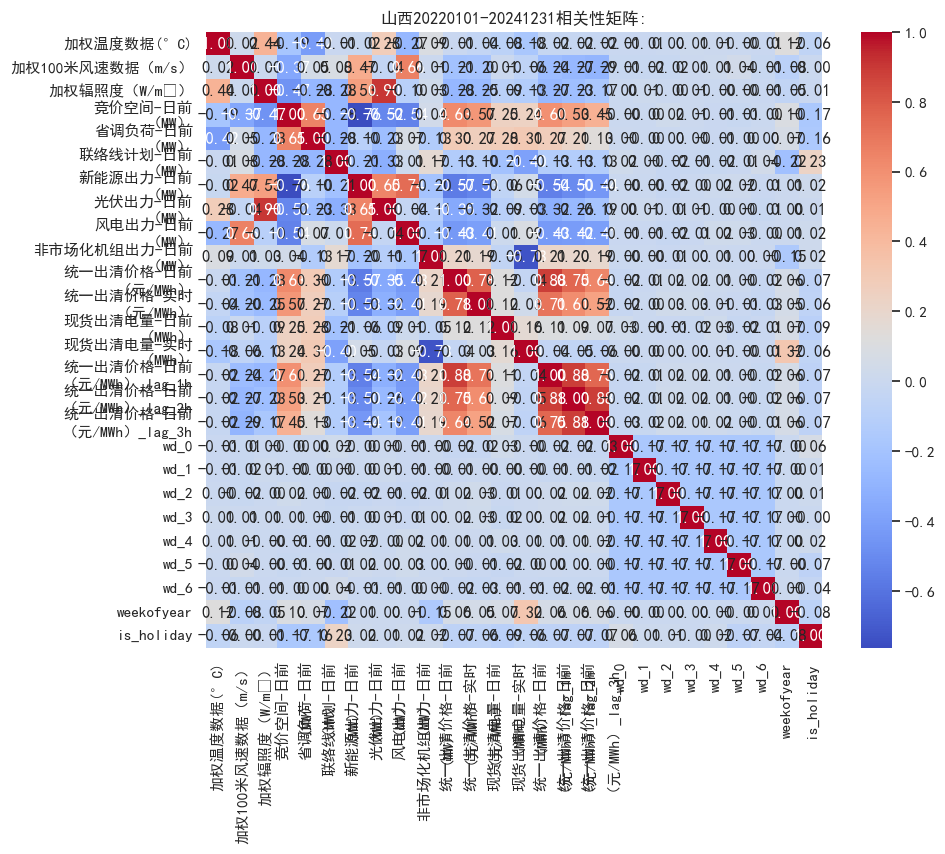

In [22]:
# 计算相关性矩阵
correlation_matrix = cleaned_merged_df.corr()

# 输出相关性矩阵
print("山西20220101-20241231相关性矩阵:")
print(correlation_matrix)

# 可视化相关性矩阵
plt.figure(figsize=(10, 8))
sns.set(font='SimHei')  # 使用 SimHei 字体

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('山西20220101-20241231相关性矩阵:')
plt.show()

# 3.电价预测

## 3.1 TimeSeriesSplit 做交叉验证 的版本

In [21]:


import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# 目标 & 特征列
target_col = '统一出清价格-日前\n（元/MWh）'

feature_cols = [
    '加权温度数据(°C)', '加权100米风速数据（m/s）', '加权辐照度（W/m²）',
    '竞价空间-日前\n（MW）', '省调负荷-日前\n（MW）', '联络线计划-日前\n（MW）',
    '新能源出力-日前\n（MW）', '光伏出力-日前\n（MW）', '风电出力-日前\n（MW）',
    '非市场化机组出力-日前\n（MW）', '现货出清电量-日前\n（MWh）',
    '统一出清价格-日前\n（元/MWh）_lag_1h', '统一出清价格-日前\n（元/MWh）_lag_2h', '统一出清价格-日前\n（元/MWh）_lag_3h', 'wd_0', 'wd_1', 'wd_2', 'wd_3', 'wd_4', 'wd_5', 'wd_6',
    'is_holiday'
]


# 构造 X 和 y
X = cleaned_merged_df[feature_cols].fillna(method='ffill').dropna()
y = cleaned_merged_df[target_col].loc[X.index]

# 定义时间序列交叉验证
tscv = TimeSeriesSplit(n_splits=5)

mae_list, rmse_list = [], []

for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # 训练模型
    model = xgb.XGBRegressor(
        n_estimators=200,        # 决策树的数量
        learning_rate=0.1,       # 学习率
        max_depth=6,             # 树的最大深度
        subsample=0.8,           # 训练每棵树时使用的样本比例
        colsample_bytree=0.8,    # 每棵树使用的特征比例
        random_state=42          # 随机种子，确保结果可复现
    )
    model.fit(X_train, y_train)
    
    # 预测
    y_pred = model.predict(X_test)
    
    # 误差指标:平均绝对误差MAE（mean absolute error） 和均方根误差 RMSE（root mean squared error)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    
    mae_relative = 1 - mae / y_test.mean()
    rmse_relative = 1 - rmse / y_test.mean()
    
    mae_list.append(mae_relative)
    rmse_list.append(rmse_relative)
    
    print(f"Fold {fold+1}: MAE_rel={mae_relative:.4f}, RMSE_rel={rmse_relative:.4f}")

# 平均指标
print("平均 MAE_relative:", np.mean(mae_list))
print("平均 RMSE_relative:", np.mean(rmse_list))


Fold 1: MAE_rel=0.7686, RMSE_rel=0.5600
Fold 2: MAE_rel=0.8388, RMSE_rel=0.7263
Fold 3: MAE_rel=0.8256, RMSE_rel=0.6725
Fold 4: MAE_rel=0.7891, RMSE_rel=0.5763
Fold 5: MAE_rel=0.8863, RMSE_rel=0.7655
平均 MAE_relative: 0.8216801771066935
平均 RMSE_relative: 0.6601151187611956


## 3.2 改进版（增加了最终训练；保存了模型；增加了预测接口---输入任意一天的特征数据（24行），输出y_pred_24h形状为(24,1)）

In [23]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib



# -------------------
# 1️⃣ 数据准备
# -------------------
target_col = '统一出清价格-日前\n（元/MWh）'

feature_cols = [
    '加权温度数据(°C)', '加权100米风速数据（m/s）', '加权辐照度（W/m²）',
    '竞价空间-日前\n（MW）', '省调负荷-日前\n（MW）', '联络线计划-日前\n（MW）',
    '新能源出力-日前\n（MW）', '光伏出力-日前\n（MW）', '风电出力-日前\n（MW）',
    '非市场化机组出力-日前\n（MW）', '现货出清电量-日前\n（MWh）',
    '统一出清价格-日前\n（元/MWh）_lag_1h', '统一出清价格-日前\n（元/MWh）_lag_2h', 
    '统一出清价格-日前\n（元/MWh）_lag_3h', 'wd_0', 'wd_1', 'wd_2', 'wd_3', 
    'wd_4', 'wd_5', 'wd_6', 'is_holiday'
]

X = cleaned_merged_df[feature_cols].fillna(method='ffill').dropna()
y = cleaned_merged_df[target_col].loc[X.index]
# 选择最后测试数据的大小
test_size = 96 * 30   # 30天 × 96点（15min 数据）
X = X.iloc[:-test_size]
y = y.iloc[:-test_size]
X_finalTest=X.iloc[-test_size:]
y_finalTest=y.iloc[-test_size:]


# -------------------
# 2️⃣ 时间序列交叉验证
# -------------------
tscv = TimeSeriesSplit(n_splits=5)
mae_list, rmse_list = [], []

for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    # 👉 想看内容，可以打印前几行
    print("\n训练集 X_sample:")
    print(X_train.head())

    print("\n验证集 X_sample:")
    print(X_test.head())

    print("\n训练集 y_sample:")
    print(y_train.head())

    print("\n验证集 y_sample:")
    print(y_test.head())


    
    model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    
    mae_relative = 1 - mae / y_test.mean()
    rmse_relative = 1 - rmse / y_test.mean()
    
    mae_list.append(mae_relative)
    rmse_list.append(rmse_relative)
    
    print(f"Fold {fold+1}: MAE_rel={mae_relative:.4f}, RMSE_rel={rmse_relative:.4f}")
    print("🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔🦔")

print("平均 MAE_relative:", np.mean(mae_list))
print("平均 RMSE_relative:", np.mean(rmse_list))

# -------------------
# 3️⃣ 使用全部数据重新训练最终模型（投产用）
# -------------------
final_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
final_model.fit(X, y)

# 保存模型
joblib.dump(final_model, 'dayahead_price_model.pkl')
print("✅ 模型已保存为 dayahead_price_model.pkl")

# -------------------
# 4️⃣ 定义生产预测函数（输入一天24小时特征 → 输出24×1电价）
# -------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm

def predict_day_ahead(model_path, day_features_df, true_prices_df=None, draw=False):
    import numpy as np
    import pandas as pd
    import joblib

    # 加载模型并进行预测
    model = joblib.load(model_path)
    preds = model.predict(day_features_df)
    pred_df = pd.DataFrame(preds, index=day_features_df.index, columns=['预测电价'])

    if draw:
        plt.figure(figsize=(12, 4))

        # ✅ 设置中文字体（解决乱码问题）
        plt.rcParams['font.sans-serif'] = ['SimHei']      # 黑体
        plt.rcParams['axes.unicode_minus'] = False         # 负号正常显示

        # 绘制预测电价
        plt.plot(pred_df.index, pred_df['预测电价'], linestyle='-', label='预测电价')

        # 如果提供了真实电价，则绘制真实电价
        if true_prices_df is not None:
            plt.plot(true_prices_df.index, true_prices_df['统一出清价格-日前\n（元/MWh）'], linestyle='--', label='统一出清价格-日前', color='orange')
            

        plt.title('日前电价预测结果（96点）', fontsize=13)
        plt.xlabel('时间', fontsize=11)
        plt.ylabel('电价（元/MWh）', fontsize=11)
        plt.legend()
        plt.grid(True, alpha=0.3)

        # ✅ 美化时间轴，只显示每小时刻度
        # plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
        # plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        plt.gcf().autofmt_xdate()  # 自动旋转、自动优化
        # ⭐ 关键：动态稀疏时间标签 ⭐
        idx = pred_df.index
        max_labels = 12
        step = max(1, len(idx) // max_labels)

        tick_pos = idx[::step]
        tick_labels = [t.strftime('%m-%d %H:%M') for t in tick_pos]

        ax = plt.gca()
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_labels, rotation=45)


        plt.tight_layout()
        plt.show()

    return pred_df



训练集 X_sample:
                     加权温度数据(°C)  加权100米风速数据（m/s）  加权辐照度（W/m²）  竞价空间-日前\n（MW）  \
datetime                                                                       
2022-01-02 02:45:00      -6.595          1.99425          0.0       31666.75   
2022-01-02 03:00:00      -6.570          2.07900          0.0       31637.90   
2022-01-02 03:15:00      -6.645          2.08750          0.0       31622.48   
2022-01-02 03:30:00      -6.720          2.09600          0.0       31579.72   
2022-01-02 03:45:00      -6.795          2.10450          0.0       31560.86   

                     省调负荷-日前\n（MW）  联络线计划-日前\n（MW）  新能源出力-日前\n（MW）  \
datetime                                                             
2022-01-02 02:45:00        28052.7         -5610.0         1995.95   
2022-01-02 03:00:00        28017.0         -5610.0         1989.10   
2022-01-02 03:15:00        27996.3         -5610.0         1983.82   
2022-01-02 03:30:00        27969.9         -5610.0         2000.18   
2022

In [72]:
# X_finalTest

In [1]:
# 示例：假设你有一天的特征数据
day_X = cleaned_merged_df[feature_cols].fillna(method='ffill').dropna().loc['2024-11-1 00:00':'2024-11-2 23:45']
day_y = cleaned_merged_df[target_col].loc[day_X.index]
day_y = pd.DataFrame(day_y)

NameError: name 'cleaned_merged_df' is not defined

In [2]:
pred_96 = predict_day_ahead('dayahead_price_model.pkl', day_X,day_y,draw=True)
metrics = evaluate_day(day_y, pred_96, draw=True)


NameError: name 'predict_day_ahead' is not defined

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
# 实际环境准确率评估函数
def evaluate_day(y_true, y_pred, draw=True):
    """
    计算单日（96点或24点）预测准确率，并可视化真实 vs 预测。
    y_true: DataFrame 或 Series（真实价格，带时间索引）
    y_pred: DataFrame（预测价格，带时间索引）
    """
    # 保证是一维
    y_true = y_true.squeeze()
    y_pred = y_pred.squeeze()
    # 对齐索引（防止有缺失）
    y_true = y_true.loc[y_pred.index]

    # 指标计算
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # 相对误差（你之前用的指标）
    mae_relative = 1 - mae / y_true.mean()
    rmse_relative = 1 - rmse / y_true.mean()

    print("📊 单日预测评估：")
    print(f"MAE: {mae:.2f} 元/MWh")
    print(f"RMSE: {rmse:.2f} 元/MWh")
    print(f"MAPE: {mape:.2f}%")
    print(f"MAE_relative: {mae_relative:.4f}")
    print(f"RMSE_relative: {rmse_relative:.4f}")

    # 可视化
    if draw:
        plt.figure(figsize=(12,4))
        plt.plot(y_true.index, y_true.values, label='日前电价', linestyle='--')
        plt.plot(y_pred.index, y_pred.values, label='日前预测电价', linestyle='-')
        plt.title("日前电价 vs 日前预测电价")
        plt.xlabel("时间")
        plt.ylabel("电价（元/MWh）")
     # ⭐ 关键：动态稀疏时间标签 ⭐
        idx = y_pred.index
        max_labels = 12
        step = max(1, len(idx) // max_labels)

        tick_pos = idx[::step]
        tick_labels = [t.strftime('%m-%d %H:%M') for t in tick_pos]

        ax = plt.gca()
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_labels, rotation=45)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "MAE_relative": mae_relative,
        "RMSE_relative": rmse_relative
    }
